### ✍ Data Preparation

Encoding:
- Gender -> ohe
- Contract -> ohe

Feature (X):

[Age, Gender, Tenure, MonthlyCharges, Contract]

Target (Y):

[Churn: No=0, Yes=1]

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

# Dataset
telco_df = pd.read_csv(r"D:\Python Course\Telco Churn Risk Analytics\data\raw\synthetic_customer_churn_100k.csv").drop_duplicates().dropna(axis=1)

#### Data Encoding & Preprocessing

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
ohe = OneHotEncoder
ss = StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", ohe(handle_unknown="ignore"), ["Gender", "Contract"]),
        ("num", ss(),["Age", "Tenure", "MonthlyCharges"])
    ]
)

#### Data Splitting

In [122]:
X = telco_df[["Age", "Gender", "Tenure", "MonthlyCharges", "Contract"]]
y = telco_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# X.head(1), y.head(1)
# X.shape, y.shape

#### Train Test Split

In [123]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# X_train.shape, X_test.shape
# y_train.shape, y_test.shape

#### Pipeline Model_1

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Model_1 (Baseline)
model_1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

# Model_1 Fit
model_1.fit(X_train, y_train)

# Model_1 Predict
yPred1 = model_1.predict(X_test)
cr1 = classification_report(y_test, yPred1, zero_division=True, output_dict=True)
print(f"Model_1 test result (Logistic Regression A):\n{cr1}")

Model_1 test result (Logistic Regression A):
{'0': {'precision': 0.755763272593604, 'recall': 0.8610745482828767, 'f1-score': 0.8049892328774786, 'support': 16714.0}, '1': {'precision': 0.6102064797716972, 'recall': 0.4386917692493362, 'f1-score': 0.5104261742610405, 'support': 8286.0}, 'accuracy': 0.72108, 'macro avg': {'precision': 0.6829848761826506, 'recall': 0.6498831587661065, 'f1-score': 0.6577077035692596, 'support': 25000.0}, 'weighted avg': {'precision': 0.7075199291807112, 'recall': 0.72108, 'f1-score': 0.7073592527296464, 'support': 25000.0}}


#### Model_1 Evaluation

Dari hasil train dan test model 1, didapatkan accuracy sekitar 0.72 accuracy dengan rata" berat F1-score 0.71. Lalu pada class 0 mendatkan performa yang lebih baik. F1-score mencapai 0.81, dibanding class 1 yang mendapat 0.51. Nilai recall rendah pada class 1 (0.44) menunjukkan kalau model 1 ini masih kesusahan untuk mengidentifikasi secara benar dari class 1.  

#### Pipeline Model_2

In [125]:
model_2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

# Model_2 fit
model_2.fit(X_train, y_train)

# Model_2 predict
yPred2 = model_2.predict(X_test)
cr2 = classification_report(y_test, yPred2, zero_division=True, output_dict=True)
print(f"Model_2 test result (Logistic Regression B):\n{cr2}")

Model_2 test result (Logistic Regression B):
{'0': {'precision': 0.8260361084716029, 'recall': 0.676139763072873, 'f1-score': 0.743609146241158, 'support': 16714.0}, '1': {'precision': 0.5217775421857055, 'recall': 0.7127685252232682, 'f1-score': 0.6024993624075491, 'support': 8286.0}, 'accuracy': 0.68828, 'macro avg': {'precision': 0.6739068253286542, 'recall': 0.6944541441480706, 'f1-score': 0.6730542543243536, 'support': 25000.0}, 'weighted avg': {'precision': 0.725192649261805, 'recall': 0.68828, 'f1-score': 0.6968397194873467, 'support': 25000.0}}


#### Model_2 Evaluation

Model 2 menggunakan class_weight="balanced" dibandingkan Model 1, accuracy mengalami penurunan dari 72% menjadi 69%. Namun, kemampuan model dalam mendeteksi customer yang melakukan churn meningkat secara signifikan, ditunjukkan oleh kenaikan recall class 1 dari 44% menjadi 71%.

Selain itu, F1-score untuk class 1 meningkat dari 0.51 menjadi 0.60. Meskipun precision mengalami penurunan dari 61% menjadi 52%, Model 2 lebih mampu mengidentifikasi customer yang berpotensi churn. Oleh karena itu, untuk tujuan churn detection, Model 2 menunjukkan performa yang lebih sesuai dibandingkan Model 1.

#### Pipeline Model_3 (Tree-Based-Model)

In [126]:
from xgboost import XGBClassifier
xgbc = XGBClassifier

model_3 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", xgbc(
        n_estimators=100,
        learning_depth=0.1,
        max_depth=5,
        tree_method="hist",
        random_state=42
    ))
])

# Model_3 fit
model_3.fit(X_train, y_train)

# Model_3 predict
yPred3 = model_3.predict(X_test)
cr3 = classification_report(y_test, yPred3, zero_division=True, output_dict=True)
print(f"Model_3 test result (XGBClassifier):\n{cr3}")


c:\Users\Diandra\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:21:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "learning_depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model_3 test result (XGBClassifier):
{'0': {'precision': 0.7943837581374821, 'recall': 0.8614933588608352, 'f1-score': 0.8265786452353616, 'support': 16714.0}, '1': {'precision': 0.663223741635147, 'recall': 0.5502051653391262, 'f1-score': 0.6014511873350924, 'support': 8286.0}, 'accuracy': 0.75832, 'macro avg': {'precision': 0.7288037498863145, 'recall': 0.7058492620999808, 'f1-score': 0.714014916285227, 'support': 25000.0}, 'weighted avg': {'precision': 0.7509120822679481, 'recall': 0.75832, 'f1-score': 0.7519624005888964, 'support': 25000.0}}


#### Model_3 Evaluation

Untuk model XGBoost dengan n_estimator=100, learning_depth=0.1, max_depth=5, tree_method="hist", random_state=42, model menghasilkan accuracy tertinggi sebesar 76% dan precision churn tertinggi sebesar 66%. Sementara itu, Logistic Regression dengan class weighting menghasilkan recall churn tertinggi sebesar 71%, sehingga lebih efektif dalam menangkap customer yang benar-benar melakukan churn.

#### Data Preprocessed

In [127]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

#### Model_4 (Neural Network)

In [128]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

# Set random seed
tf.random.set_seed(42)

# Model_4
model_4 = Sequential(
    [
        Dense(4, activation="relu"),
        Dense(4, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)

# Model_4 compile
model_4.compile(
    loss=BinaryCrossentropy(), optimizer=Adam(learning_rate=0.01), metrics=["accuracy"]
)

# Early stop
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Class weight
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))


# Model_4 fit
history = model_4.fit(
    X_train_preprocessed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6502 - loss: 0.5727 - val_accuracy: 0.7253 - val_loss: 0.5022
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6884 - loss: 0.5262 - val_accuracy: 0.7417 - val_loss: 0.4873
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.6963 - loss: 0.5133 - val_accuracy: 0.7401 - val_loss: 0.4912
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7084 - loss: 0.5098 - val_accuracy: 0.7439 - val_loss: 0.4865
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7285 - loss: 0.5070 - val_accuracy: 0.7462 - val_loss: 0.4827
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.7335 - loss: 0.5064 - val_accuracy: 0.7485 - val_loss: 0.4850
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7335 - loss: 0.5054 - val_accuracy: 0.7498 - val_loss: 0.4835
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7328 - loss: 0.50

<Axes: >

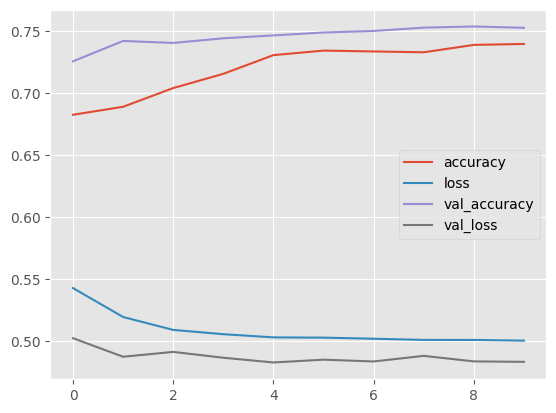

In [129]:
pd.DataFrame(history.history).plot()

#### Model_4 Predict

In [130]:
# Predict prob
yPred_prob = model_4.predict(X_test_preprocessed)

yPred4 = (yPred_prob >=0.5).astype(int)
cr4 = classification_report(y_test, yPred4, zero_division=True,output_dict=True)
print(f"Model 4 test result (Neural Network):\n{cr4}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Model 4 test result (Neural Network):
{'0': {'precision': 0.806290710639047, 'recall': 0.8220653344501615, 'f1-score': 0.8141016145756185, 'support': 16714.0}, '1': {'precision': 0.6263349667043598, 'recall': 0.6016171856142891, 'f1-score': 0.6137273007079102, 'support': 8286.0}, 'accuracy': 0.749, 'macro avg': {'precision': 0.7163128386717035, 'recall': 0.7118412600322253, 'f1-score': 0.7139144576417643, 'support': 25000.0}, 'weighted avg': {'precision': 0.7466461788693343, 'recall': 0.749, 'f1-score': 0.7476895519873051, 'support': 25000.0}}


### ⚖️ Model Comparison

In [131]:
models_compare = pd.DataFrame({
    "model_1 (LogReg1)": cr1["weighted avg"],
    "model_2 (LogReg2)": cr2["weighted avg"],
    "model_3 (Xgboost)": cr3["weighted avg"],
    "model_4 (NN)": cr4["weighted avg"]
}).T.drop(columns="support", axis=1)


models_compare_acc = pd.DataFrame({
    "model_1 (LogReg1)": [cr1["accuracy"]],
    "model_2 (LogReg2)": [cr2["accuracy"]],
    "model_3 (Xgboost)": [cr3["accuracy"]],
    "model_4 (NN)": [cr4["accuracy"]]
})


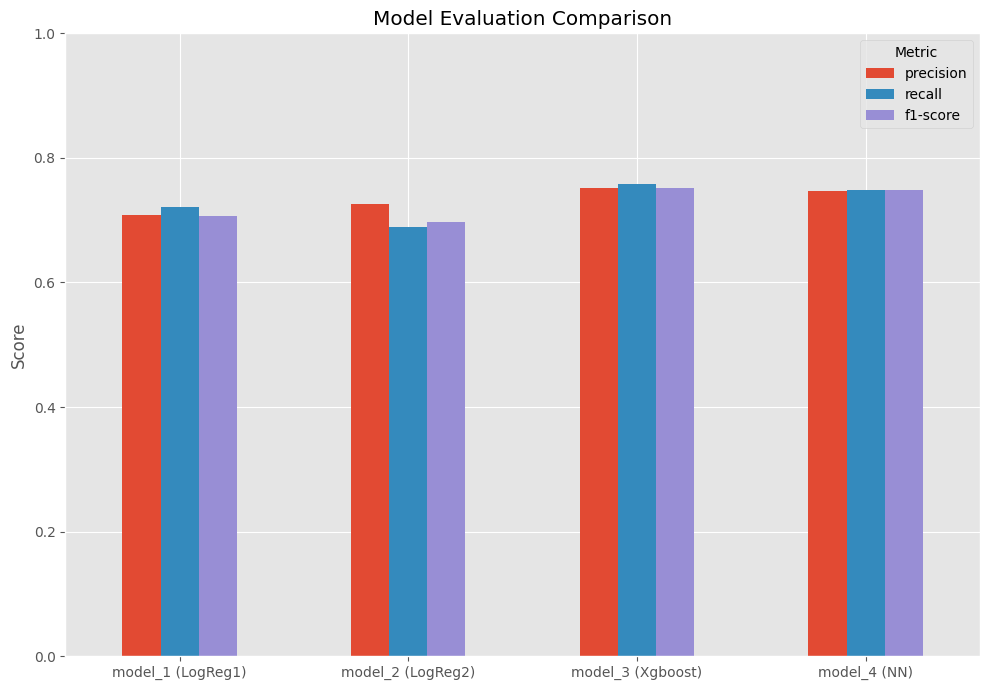

In [132]:
models_compare.plot(kind="bar", figsize=(10, 7))

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Evaluation Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

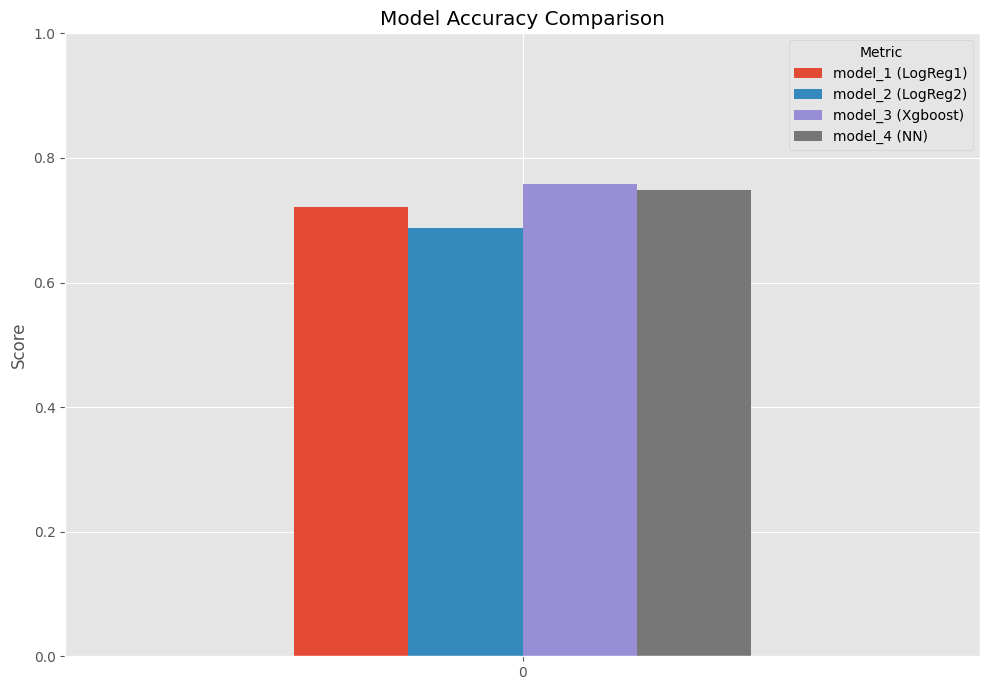

In [133]:
models_compare_acc.plot(kind="bar", figsize=(10, 7))

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### 📊 Model Evaluation Summary

Empat model machine learning telah diuji untuk memprediksi kemungkinan customer melakukan churn, yaitu Logistic Regression, Logistic Regression dengan `class_weight="balanced"`, XGBoost, dan Neural Network dengan `class_weight`. Berdasarkan hasil evaluasi, setiap model menunjukkan karakteristik performa yang berbeda pada class **Churn (1)**.

**Logistic Regression** memperoleh accuracy sebesar **72%**, dengan recall churn sebesar **44%**. Setelah menggunakan `class_weight="balanced"`, recall meningkat cukup signifikan menjadi **71%**, meskipun accuracy turun menjadi **69%**. Hal ini menunjukkan bahwa class weighting membantu model dalam mendeteksi lebih banyak customer yang melakukan churn.

**XGBoost** menghasilkan accuracy tertinggi sebesar **76%**, dengan precision churn sebesar **66%**, recall **55%**, dan F1-score **60%**. Sementara itu, **Neural Network dengan class weighting** memperoleh accuracy sebesar **75%**, precision **64%**, recall **57%**, dan F1-score **61%**, sehingga menghasilkan F1-score churn tertinggi dari keempat model.

Berdasarkan hasil tersebut, **XGBoost unggul dari sisi accuracy**, sedangkan **Logistic Regression Balanced memiliki recall churn tertinggi**. Neural Network menghasilkan **F1-score churn tertinggi**, sehingga menunjukkan performa yang relatif seimbang antara precision dan recall. Pemilihan model akhir perlu disesuaikan dengan tujuan bisnis, terutama apakah perusahaan lebih memprioritaskan **menangkap sebanyak mungkin customer yang berpotensi churn** atau menjaga agar prediksi churn tetap lebih tepat.
